# Práctica 4 - Filtrado de Spam usando Bayes Ingenuo

Empezaremos la practica realizando un **Aprendizaje Supervisado**.
Donde entrenaremos un modelo con una gran cantidad de datos para que aprenda a elegir por si mismo a filtrar los correos.

Donde deberemos asignar a cada uno de los correos la etiqueta: y=SPAM o y=HAM.

Después de darle los ejemplos (Enron1-5), la máquina habrá aprendido una "función" o un conjunto de reglas para que, cuando le demos los correos nuevos (Enron6), pueda adivinar las etiquetas correctas.

Donde la máquina convierte el correo en una lista de atributos (features). Esos atributos son las palabras que contiene (ej: "gratis", "oferta") o bigramas (grupos de dos palabras, ej: "haga click").
****
El Teorema de Bayes. Donde querremos su probabilidad. Para dado un correo con ciertas palabras (X), ¿cuál es la probabilidad de que sea SPAM (C)? O $P(SPAM | \text{palabras del correo})$. Nuestro Teorema de Bayes: nas dara la vuelta a esa pregunta, por comodidad $P(\text{palabras del correo} | SPAM)$8. De todos los correos de spam que tengo, ¿cuántos contienen la palabra 'gratis'?.
****
La parte "Ingenua" (Naive), Calcular la probabilidad de una combinación de palabras (ej: "oferta" Y "gratis") es demasiado complejo.

Por lo cual modelo hace una suposición ingenua (y falsa, pero útil): asumiendo que todas las palabras son independientes entre sí. (El modelo cree que la probabilidad de que aparezca "oferta" no tiene nada que ver con la probabilidad de que aparezca "gratis". Simplemente multiplica sus probabilidades.)

Por lo cual haremos una bolsa de Palabras. Al modelo no le importa el orden de las palabras, solo cuántas veces o cuales aparecen. Para él, "oferta gratis aquí" es lo mismo que "aquí" "gratis" "oferta".
****
Por parte del Cero y el Suavizado, puesto que puede haber palabras que nunca aparezcan en los correos de SPAM de entrenamiento (Enron1-5). Nuestro modelo calculará: $P(\text{"PalabraRandom"} | SPAM) = 0$. Como el modelo multiplica todas las probabilidades, ese 0 hará que la probabilidad final de que el correo sea SPAM sea 0, incluso si también contiene "gratis" u "oferta".

Por lo cual realizamos un suavizado de Laplace (parámetro $\alpha$) sirviendo como parche. Le sumaremos una pequeña cantidad (llamada alpha) al contador de cada palabra.
 Ninguna probabilidad será jamás 0. Este alpha ($\alpha$) lo iremos ajustaremos.
****
Bernoulli vs. Multinomial. Son dos tipos distintos de Naive Bayes.
1. Clasificador Multinomial: Cuenta cuántas veces aparece cada palabra.Ejemplo: Un correo que dice "oferta oferta gratis" es diferente a "oferta gratis". La palabra "oferta" tiene un peso de 2 en el primer caso.
Generalmente funciona mejor para textos más largos, donde la frecuencia de una palabra es una pista importante.

2. Clasificador Bernoulli: Solo le importa si una palabra aparece o no aparece (es binario). Entonces "oferta oferta gratis" y "oferta gratis" son idénticos para este modelo. Solo registra: "sí, 'oferta' está presente" y "sí, 'gratis' está presente".
A veces funciona mejor para textos cortos o cuando la sola presencia de una palabra (por ejemplo: "viagra") es una señal de alarma suficiente. Veremos para nuestros experimentos cual es el mejor.
****
Para los Bigramas, la suposición ingenua de independencia es muy fuerte. Por ejemplo, "click" y "aquí" no son independientes; a menudo van juntos. Con los bigramas: En lugar de tratar "click" y "aquí" como dos atributos separados, trataremos el par "click aquí" como un solo atributo. Esto captura un poco más de contexto. Comprobando si la utilización de esto mejora el resultado, lo enfrentaremos al final.
****
Despues realizaremos la comprobación. Train / Validation / Test:
1. Entrenamiento (Train): Donde encontraremos la mayoria de la información para entrenar el modelo.
2. Validación (Validation): Usas el resto (ej: 20% de Enron1-5) para comparar tus modelos 24 (ej: ¿Bernoulli con $\alpha=1$ es mejor que Multinomial con $\alpha=0.1$?).
3. Test (Enron6): Una vez que has elegido tu único modelo ganador, usaremos Enron6 (datos diferentes a los anteriores) para darle su nota final.

Errores (Diap. 15):
1. Falso Positivo (FP): El peor error para el filtro de spam. Es un correo HAM que tu filtro clasifica como SPAM.
2. Falso Negativo (FN): Un error molesto, pero menos grave. Es un correo SPAM (malo) que tu filtro clasifica como HAM.

Precision vs. Recall:
1. Precisión (Precision): De todos los que dijimos ser spam, ¿cuántos acerto?. Una precisión alta significa pocos Falsos Positivos (FP).
2. Recall (Exhaustividad): De todos los que eran spam de verdad, ¿cuántos maté?. Un recall alto significa pocos Falsos Negativos (FN).
3. El Dilema del SPAM: Para un filtro de spam, queremos maximizar la precisión. Preferimos que se cuele algo de spam a cambio de estar 100% seguro de quitar correo bueno (Precisión altísima).

****
****
Punto 3.3.1 (Validación): Vamos a coger Enron1-5, partirlo en train" y val. Usaremos train para entrenar y val para medir el F1-Score y comprobar todas las combinaciones:Bernoulli vs. Multinomial,
Diferentes $\alpha$ (suavizado), Palabras vs. Bigramas

Punto 3.3.2 (Test): Elegiremos al ganador y lo evaluaremos una sola vez con Enron6 para sacar la matriz de confusión y la curva P-R.

Imports necesarios para ejecutar la práctica

In [ ]:
import numpy as np
import json
import glob
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.utils import shuffle
from sklearn import metrics
from sklearn.model_selection import KFold, train_test_split

Carga del fichero ZIP con todos los correos

In [ ]:
!gdown 1hYha8kSpbAhGIHAfygLFmGHIzHGAK5f8
!unzip -qn "enron.zip"

Downloading...
From (original): https://drive.google.com/uc?id=1hYha8kSpbAhGIHAfygLFmGHIzHGAK5f8
From (redirected): https://drive.google.com/uc?id=1hYha8kSpbAhGIHAfygLFmGHIzHGAK5f8&confirm=t&uuid=9596e6b8-04b8-4d4e-aa9b-4fc0d644dce7
To: /content/enron.zip
100% 28.9M/28.9M [00:00<00:00, 55.3MB/s]


Lectura de los emails y carga en las estructuras de datos

In [ ]:
def read_folder(folder):
    mails = []
    file_list = glob.glob(folder)  # List mails in folder
    num_files = len(file_list)
    for i in range(0, num_files):
        i_path = file_list[i]
        i_file = open(i_path, 'rb')
        i_str = i_file.read()
        i_text = i_str.decode('utf-8', errors='ignore')  # Convert to Unicode
        mails.append(i_text)  # Append to the mail structure
        i_file.close()
    return mails

def load_enron_folders(datasets):
    path = './'
    ham = []
    spam = []
    for j in datasets:
        ham  = ham  + read_folder(path + '/enron' + str(j) + '/ham/*.txt')
        spam = spam + read_folder(path + '/enron' + str(j) + '/spam/*.txt')
    num_ham  = len(ham)
    num_spam = len(spam)
    print("mails:", num_ham+num_spam)
    print("ham  :", num_ham)
    print("spam :", num_spam)

    mails = ham + spam
    labels = [0]*num_ham + [1]*num_spam
    mails, labels = shuffle(mails, labels, random_state=0)
    return mails, labels

print("Loading files...")

print("------Loading train and validation data--------")
mails, y = load_enron_folders([1,2,3,4,5])

print("--------------Loading test data----------------")
mails_test, y_test = load_enron_folders([6])
#Partimos los datos en 80% entrenar y 20% validar.
mails_entr, mails_val, y_entr, y_val = train_test_split(mails, y, test_size=0.2, random_state=0)
#Definimos variable para la aleatoriedad para que ambos prototipos relicen el mismo examen

Loading files...
------Loading train and validation data--------
mails: 27716
ham  : 15045
spam : 12671
--------------Loading test data----------------
mails: 6000
ham  : 1500
spam : 4500


Código para generar una bolsa de palabras que cuenta el número de apariciones de cada palabra en la lista de correos

Crea una matriz X con tantas filas como correos (27716) y tantas columnas como palabras en el conjunto de datos. El elemento (i,j) de la matriz contiene el número de ocurrencias de la palabra j en el correo i

CountVectorizer: Todavía no ha hecho nada, solo has creado una máquina vacía que sabe cómo "vectorizar" (convertir texto en números).ngram_range=(1, 1), le está ordenando: "Quiero que tus características (tus "fichas") sean palabras individuales."

.fit() (Aprender el Vocabulario):
Donde leera los correos de mails y construye un vocabulario gigante (un diccionario) con cada palabra única que encuentra.
Esto es de "aprender" o "ajustar" (fit).

.transform() (Crear la Matriz Numérica):
Ahora que ya tiene el vocabulario (las columnas), vuelve a repasar cada correo (cada fila) y cuenta cuántas veces aparece cada palabra de ese vocabulario.

X: Es el resultado. Una matriz (tabla) gigante donde las filas son los correos y las columnas son las palabras. El valor de cada celda es el número de veces que esa palabra aparece en ese correo.

In [ ]:
vectorizer = CountVectorizer(ngram_range=(1, 1))  # Instancia de bolsa de palabras con palabras individuales como características
#X = vectorizer.fit_transform(mails)               # Generación y cálculo de la bolsa de palabras en base a los datos de entrenamiento
#Ahora diccionaremos las palabras por realmente el tipo que son segun el tipo del anterior filtro
X_entr = vectorizer.fit_transform(mails_entr) #Tipado para el entreno
X_val = vectorizer.transform(mails_val)#ya ni necesitamos volver a entrenar o buscar un nue
X_test = vectorizer.transform(mails_test)         # Cálculo de la bolsa de palabras con los datos de test, ya no hace falta diccionarlo de nuevo. Se guarda en vectorizer

Aprendizaje de las probabilidades utilizando un modelo de distribución Bernoulli.

Consulta la documentación de sklearn para entender los parámetros.

In [ ]:
classifier_ber = BernoulliNB(alpha=1.0, fit_prior=True, class_prior=None) # Instancia de clasificador de Bayes Ingenuo con distribución de Bernoulli
classifier_ber.fit(X_entr, y_entr) # Cálculo de las probabilidades asociadas a cada palabra de la bolsa

classifier_multi = MultinomialNB(alpha=1.0, fit_prior=True, class_prior=None)
# Entrena con los MISMOS datos de entrenamiento
classifier_multi.fit(X_entr, y_entr)


MultinomialNB()

Crea un clasificador de Bayes Ingenuo tipo Bernoulli.

BernoulliNB: Este modelo es binario. Solo le importa si una palabra está o no está en el correo (1 o 0). Le da igual si la palabra "oferta" aparece 1 vez o 50 veces; para él es lo mismo.

MultinomialNB: A este modelo sí le importa la frecuencia. Cuenta cuántas veces aparece cada palabra. Un correo con 10 veces la palabra "gratis" tendrá más peso de spam que uno que solo la tenga 1 vez. Suele funcionar mejor en textos largos.



Cálculo de métricas del clasificador utilizando los datos de test

F1-score Bernoulli (Validation): 98.68%
Confusion Matrix (Bernoulli):
[[2965   45]
 [  22 2512]]
F1-score Multinomial (Validation): 98.74%
Confusion Matrix (Multinomial):
[[2982   28]
 [  36 2498]]


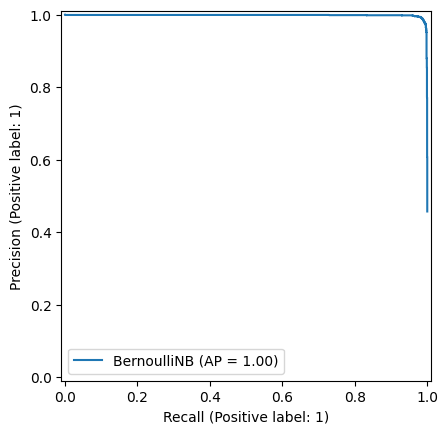

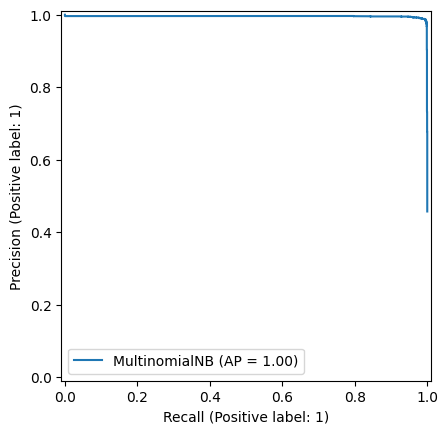

In [ ]:
y_pred_ber = classifier_ber.predict(X_val)
f1_score_ber = metrics.f1_score(y_val, y_pred_ber)
print(f"F1-score Bernoulli (Validation): {100*f1_score_ber:2.2f}%")
C_ber = metrics.confusion_matrix(y_val, y_pred_ber)
print("Confusion Matrix (Bernoulli):")
print(C_ber)
metrics.PrecisionRecallDisplay.from_estimator(classifier_ber, X_val, y_val)

y_pred_multi = classifier_multi.predict(X_val)
f1_score_multi = metrics.f1_score(y_val, y_pred_multi)
print(f"F1-score Multinomial (Validation): {100*f1_score_multi:2.2f}%")
C_multi = metrics.confusion_matrix(y_val, y_pred_multi)
print("Confusion Matrix (Multinomial):")
print(C_multi)
metrics.PrecisionRecallDisplay.from_estimator(classifier_multi, X_val, y_val)

Los Ejes
Eje Y (Precision / Precisión): Mide la calidad de tus predicciones de Spam.

Si está en 1.0 (arriba del todo), significa: "De todos los correos que mandé a la carpeta de Spam, el 100% eran realmente Spam (no cometí errores graves)".

Eje X (Recall / Exhaustividad): Mide la cantidad de Spam que has detectado.

Si está en 1.0 (a la derecha del todo), significa: "De todo el Spam que llegó a la bandeja de entrada, lo detecté todo (no se me escapó nada)".

La imagen te dice que el modelo es muy bueno, pero te advierte de que si intentas ser demasiado ambicioso detectando el 100% del spam, empezarás a cometer errores.

La parte plana superior: Fíjate que la línea se mantiene pegada al techo (Precision $\approx$ 1.0) durante casi todo el recorrido hacia la derecha.Significado: Tu modelo es excelente. Es capaz de detectar una gran cantidad de Spam (Recall alto, cerca de 0.8 o 0.9) manteniendo una precisión casi perfecta.La caída final (a la derecha): Justo al final, cuando intentas llegar al Recall 1.0 (detectar absolutamente todo el spam), la línea cae en picado.Significado: Para cazar esos últimos correos de spam difíciles y ambiguos, el modelo tiene que "arriesgarse" más. Al arriesgarse, empieza a equivocarse y a clasificar correos legítimos como spam, por lo que la precisión baja.

Este anterior test puede servir como una pequeña aproximación, pero ahora a mejor probaremos una comprobación robusta con varias alphas a probar. Y comprobar de paso los bigramas como nos habian pedido, o en otras palabras, haremos toda la estructura de la practica aqui. Lo anterior podria servir como calentamiento o entendimiento de todo el entorno.

In [ ]:
#Empezamos como el principio
ngram_configs = [(1, 1), (1, 2)]
# MEJOR 'alpha': 0.003 para ahorrar tiempo de corrección
alphas_a_probar = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007] #Tras comprobar y estudiar varios resultados estos eran los mejores para este caso, no queremos saturar el programa demasiado
modelos_a_probar = ["Bernoulli", "Multinomial"]

mejor_fbeta_score = -1.0 #Medidor de rendimiento
mejor_configuracion = {"modelo": "", "alpha": 0.0, "ngram_range": (0,0)}
#Empezamos probando los 2 tipo de gramas
for ngram_config in ngram_configs:
  #asignamos como siemper
  vectorizer = CountVectorizer(ngram_range=ngram_config)
  X_entr = vectorizer.fit_transform(mails_entr)
  X_val = vectorizer.transform(mails_val)
  #Comparacion de modelos
  for nombre_modelo in modelos_a_probar:
    for alpha_actual in alphas_a_probar:
      if nombre_modelo == "Bernoulli":
        clasificador = BernoulliNB(alpha=alpha_actual, fit_prior=True, class_prior=None)
      else:
        clasificador = MultinomialNB(alpha=alpha_actual, fit_prior=True, class_prior=None)
      clasificador.fit(X_entr, y_entr)
      y_pred_val = clasificador.predict(X_val)
      #Usando la formula de las diapo en vez de la media, obtener mejor precisión
      fbeta_actual = metrics.fbeta_score(y_val, y_pred_val, beta=0.00005)

      if fbeta_actual > mejor_fbeta_score:
        mejor_fbeta_score = fbeta_actual
        mejor_configuracion["modelo"] = nombre_modelo
        mejor_configuracion["alpha"] = alpha_actual
        mejor_configuracion["ngram_range"] = ngram_config
print(f"El mejor fue: {mejor_fbeta_score*100:.2f}%")
print(f"Con: {mejor_configuracion}")

El mejor fue: 99.80%
Con: {'modelo': 'Multinomial', 'alpha': 0.003, 'ngram_range': (1, 2)}


Una vez hallado el mejor modelo solo nos falta printar su eficiencia con un conjunto diferente al del entrenamiento y hallar su curva.

In [ ]:
X_entr = vectorizer.fit_transform(mails)
clasificador.fit(X_entr, y)
X_test = vectorizer.transform(mails_test)
probabilidades_completas = clasificador.predict_proba(X_test)

# Nos quedamos la probabilidad de que sea SPAM
probabilidad_de_spam = probabilidades_completas[:, 1]
#Queremos no matar correos ham, queremos que este muy muy seguro el filtrado antes de descartar aunque descartemos menos
umbral = 0.9999999999999999

#Solo lo filtraremos si vence nuestro umbral, pasandola a int para su cumparación
y_pred_ajustada = (probabilidad_de_spam > umbral).astype(int)

f1_ajustado = metrics.f1_score(y_test, y_pred_ajustada)
print(f"F1-Score (Ajustado): {f1_ajustado * 100:.2f}%")

precision_ajustada = metrics.precision_score(y_test, y_pred_ajustada, zero_division=0) # Ponemos zero_division por si acaso
print(f"Precision (Ajustada): {precision_ajustada * 100:.2f}%")

recall_ajustado = metrics.recall_score(y_test, y_pred_ajustada)
print(f"Recall (Ajustado): {recall_ajustado * 100:.2f}%")

C_ajustada = metrics.confusion_matrix(y_test, y_pred_ajustada)
print(f"\nNueva Matriz de Confusión (Umbral {umbral}):")
print("           Predicho HAM | Predicho SPAM")
print("------------------------|--------------------------------------")
print(f"Real HAM:    {C_ajustada[0][0]:<10} | {C_ajustada[0][1]:<10}   (Falsos Positivos: {C_ajustada[0][1]})")
print(f"Real SPAM:   {C_ajustada[1][0]:<10} | {C_ajustada[1][1]:<10}   (Falsos Negativos: {C_ajustada[1][0]})")

F1-Score (Ajustado): 97.81%
Precision (Ajustada): 99.61%
Recall (Ajustado): 96.07%

Nueva Matriz de Confusión (Umbral 0.9999999999999999):
           Predicho HAM | Predicho SPAM
------------------------|--------------------------------------
Real HAM:    1483       | 17           (Falsos Positivos: 17)
Real SPAM:   177        | 4323         (Falsos Negativos: 177)


Para esta matriz, esta es la clave de todo la practica la cual representa lo que buscabamos.

Precisión (Ajustada): 99.61%. Esto significa que de cada 1000 correos, 996 lo son de verdad. Nuestro objetivo prioritario, no mandar a spam correos importantes. Es normal que un pequeño porcentaje se manden aqui, puesto que a saber lo que puede llegar a poner.

Falsos Positivos (FP): 17, un muy buen resultado y aun podriamos incrementarlo mas pero al precio de FN. Tal vez dividorlo por a la mitad si lo consiguieramos saldria a precio de un muy peor filtro.

Falsos Negativos (FN): 177 Aquí está el precio a pagar. Para conseguir esa precisión tan alta, hemos dejado que se cuelen 177 spams. Es una molestia, pero no perdemos tantos correos importantes.

In [ ]:
import pandas as pd

#recalcular las predicciones con tu umbral (por si acaso)
umbral = 0.9999999999999999
probs = clasificador.predict_proba(X_test)[:, 1]
preds = (probs > umbral).astype(int)

#Crear un DataFrame para facilitar la búsqueda, tipo tabla (Texto, Real, Predicho, Probabilidad)
df_resultados = pd.DataFrame({
    'texto': mails_test,
    'real': y_test,
    'predicho': preds,
    'prob_spam': probs
})

#Filtrar los casos interesantes
# Falsos Positivos: Era HAM (0) pero dijimos SPAM (1) Peor caso
falsos_positivos = df_resultados[(df_resultados['real'] == 0) & (df_resultados['predicho'] == 1)]

# Falsos Negativos: Era SPAM (1) pero dijimos HAM (0)
falsos_negativos = df_resultados[(df_resultados['real'] == 1) & (df_resultados['predicho'] == 0)]

# Imprimir ejemplos para discutir
print(f"Falsos Positivos: {len(falsos_positivos)})")

if not falsos_positivos.empty:
    # Cogemos el primero como ejemplo
    ejemplo = falsos_positivos.iloc[0]
    print(f"Probabilidad asignada de Spam: {ejemplo['prob_spam']:.4f}")
    print("CONTENIDO DEL CORREO:")
    print(ejemplo['texto'][:1000]) # Imprimimos solo los primeros 1000 caracteres
else:
    print("No hubo falsos positivos .")

print(f"ANÁLISIS DE SPAM NO DETECTADO (Falsos Negativos: {len(falsos_negativos)})")


if not falsos_negativos.empty:
    #Cogemos el primero
    ejemplo = falsos_negativos.iloc[0]
    print(f"Probabilidad asignada de Spam: {ejemplo['prob_spam']:.4f} (El umbral era {umbral})")
    print("CONTENIDO DEL CORREO:")
    print(ejemplo['texto'][:1000])
else:
    print("No hubo falsos negativos .")

Falsos Positivos: 17)
Probabilidad asignada de Spam: 1.0000
CONTENIDO DEL CORREO:
Subject: a premier designs jewelry show
lisa fawcett has invited you to " a premier designs jewelry show " .
click below to visit evite for more information about the event and also to rsvp .
this invitation was sent to you by lisa fawcett using evite . to remove yourself
from this guest list please contact us at support @ evite . citysearch . com
this evite invite is covered by evite ' s privacy policy * .
to view this privacy policy , click here :
http : / / evite . citysearch . com / privacy
* * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * *
* * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * *
having trouble ?
perhaps your email program doesn ' t recognize the web address as an active
link . to view your invitation , copy the entire url and paste it into your browser .
if you would like further assistance , please send
email to support @ evite . citysearch . com
* updated 03

Falso Positivo (FP): El correo de "Jewelry Show"
El filtrado falló en este correo legítimo debido a su alta similitud estadística con patrones de campañas de SPAM.

Causa del fallo: El modelo detectó un vocabulario puramente comercial ("jewelry", "premier designs", "show") y estructuras típicas de spam como "click below" o instrucciones para "darse de baja de la lista" (remove yourself from this guest list).

Para el algoritmo Naive Bayes, estas palabras tienen una probabilidad altísima de pertenecer a la clase SPAM según los datos de entrenamiento. Al coincidir tantas "marcas" de spam en un mismo correo, la probabilidad final superó incluso el umbral restrictivo que habías fijado, provocando que un correo bueno acabara en la carpeta de correo basura.

----
Falso Negativo (FN): El correo de "Urgent Update"
En este caso, el filtrado falló porque el atacante utilizó una técnica de Envenenamiento Bayesiano (Bayesian Poisoning).

Causa del fallo: Los creadores del spam "llenaron" el correo con palabras totalmente neutras o positivas que no tienen nada que ver con el mensaje basura ("engine", "tree", "cold", "school", "home", "mile") para bajar la probabilidad de ser seleccionado como SPAM.

El modelo Naive Bayes asume que las palabras son independientes entre sí. Al incluir tantos términos comunes en correos legítimos (HAM), la probabilidad total de SPAM se "diluye". Como habiamos configurado un umbral de seguridad extremadamente alto (0.9999999999999999) para proteger los correos buenos, la mezcla de palabras neutras hizo que este correo basura no llegara a esa cifra mínima exigida para ser bloqueado, logrando así colarse en la bandeja de entrada.